# Phase 7 — PGD Adversarial Attack

This experiment evaluates the robustness of the neural-network
IDS against Projected Gradient Descent (PGD).

PGD performs multiple gradient-based updates while projecting
the adversarial example back into an L-infinity perturbation
region of radius epsilon.

Attack objective:

ATTACK → BENIGN

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

sys.path.append("..")

from src.attacks.pgd import pgd_attack

In [2]:
SPLIT_DIR = Path("../data/splits")
MODEL_DIR = Path("../models")
RESULTS_DIR = Path("../experiments/results")

X_val = pd.read_csv(
    SPLIT_DIR / "X_val.csv"
)

y_val = pd.read_csv(
    SPLIT_DIR / "y_val.csv"
).squeeze()

print("Validation shape:", X_val.shape)
print("Labels shape:", y_val.shape)

Validation shape: (378120, 70)
Labels shape: (378120,)


In [3]:
class IDSNeuralNetwork(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

input_size = X_val.shape[1]

model = IDSNeuralNetwork(
    input_size
).to(device)

model.load_state_dict(
    torch.load(
        MODEL_DIR / "neural_network_baseline.pth",
        map_location=device
    )
)

model.eval()

print("Device:", device)
print("Model loaded successfully.")

Device: cpu
Model loaded successfully.


In [5]:
X_val_tensor = torch.tensor(
    X_val.values,
    dtype=torch.float32,
    device=device
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32,
    device=device
).view(-1, 1)

In [6]:
loss_fn = nn.BCEWithLogitsLoss()

In [7]:
model.eval()

with torch.no_grad():

    clean_logits = model(
        X_val_tensor
    )

    clean_probabilities = torch.sigmoid(
        clean_logits
    ).cpu().numpy().ravel()

    clean_predictions = (
        clean_probabilities >= 0.5
    ).astype(int)

In [8]:
attack_mask = (
    (y_val.values == 1) &
    (clean_predictions == 1)
)

print(
    "Actual attacks:",
    (y_val.values == 1).sum()
)

print(
    "Correctly detected attacks:",
    attack_mask.sum()
)

Actual attacks: 63861
Correctly detected attacks: 60193


In [9]:
X_attack = X_val_tensor[attack_mask]

y_attack = y_val_tensor[attack_mask]

print(
    "Attack samples:",
    X_attack.shape[0]
)

Attack samples: 60193


In [10]:
epsilon = 0.01
num_steps = 10
alpha = epsilon / num_steps

In [11]:
X_attack_adv = pgd_attack(
    model=model,
    x=X_attack,
    y=y_attack,
    epsilon=epsilon,
    alpha=alpha,
    num_steps=num_steps,
    loss_fn=loss_fn
)

In [12]:
perturbation = (
    X_attack_adv -
    X_attack
)

max_perturbation = (
    perturbation.abs().max().item()
)

mean_perturbation = (
    perturbation.abs().mean().item()
)

print(
    "Maximum perturbation:",
    max_perturbation
)

print(
    "Mean absolute perturbation:",
    mean_perturbation
)

print(
    "Epsilon:",
    epsilon
)

Maximum perturbation: 0.010000228881835938
Mean absolute perturbation: 0.004879172425717115
Epsilon: 0.01


In [13]:
model.eval()

with torch.no_grad():

    adv_logits = model(
        X_attack_adv
    )

    adv_probabilities = torch.sigmoid(
        adv_logits
    ).cpu().numpy().ravel()

    adv_predictions = (
        adv_probabilities >= 0.5
    ).astype(int)

In [14]:
successful_evasions = (
    adv_predictions == 0
).sum()

total_attacks = len(
    adv_predictions
)

attack_success_rate = (
    successful_evasions /
    total_attacks
)

print(
    "Successful evasions:",
    successful_evasions
)

print(
    "Total correctly detected attacks:",
    total_attacks
)

print(
    "Attack Success Rate:",
    attack_success_rate
)

Successful evasions: 14957
Total correctly detected attacks: 60193
Attack Success Rate: 0.24848404299503266


In [15]:
X_val_adv = pgd_attack(
    model=model,
    x=X_val_tensor,
    y=y_val_tensor,
    epsilon=epsilon,
    alpha=alpha,
    num_steps=num_steps,
    loss_fn=loss_fn
)

In [16]:
with torch.no_grad():

    adv_logits_all = model(
        X_val_adv
    )

    adv_prob_all = torch.sigmoid(
        adv_logits_all
    ).cpu().numpy().ravel()

    adv_pred_all = (
        adv_prob_all >= 0.5
    ).astype(int)

In [17]:
def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    fpr = fp / (fp + tn)

    fnr = fn / (fn + tp)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "FPR": fpr,
        "FNR": fnr,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [18]:
EPSILONS = [
    0.001,
    0.005,
    0.01,
    0.05,
    0.1
]

In [19]:
pgd_results = []

num_steps = 10

for epsilon in EPSILONS:

    print(
        f"\nRunning PGD with epsilon = {epsilon}"
    )

    alpha = epsilon / num_steps

    # Generate adversarial validation set
    X_adv = pgd_attack(
        model=model,
        x=X_val_tensor,
        y=y_val_tensor,
        epsilon=epsilon,
        alpha=alpha,
        num_steps=num_steps,
        loss_fn=loss_fn
    )

    # Predict
    with torch.no_grad():

        logits = model(X_adv)

        probabilities = torch.sigmoid(
            logits
        ).cpu().numpy().ravel()

        predictions = (
            probabilities >= 0.5
        ).astype(int)

    # Overall metrics
    metrics = calculate_metrics(
        y_val,
        predictions,
        probabilities
    )

    # Attack success rate
    X_attack_adv = pgd_attack(
        model=model,
        x=X_attack,
        y=y_attack,
        epsilon=epsilon,
        alpha=alpha,
        num_steps=num_steps,
        loss_fn=loss_fn
    )

    with torch.no_grad():

        attack_logits = model(
            X_attack_adv
        )

        attack_probabilities = torch.sigmoid(
            attack_logits
        ).cpu().numpy().ravel()

        attack_predictions = (
            attack_probabilities >= 0.5
        ).astype(int)

    successful_evasions = (
        attack_predictions == 0
    ).sum()

    attack_success_rate = (
        successful_evasions /
        len(attack_predictions)
    )

    metrics["Epsilon"] = epsilon

    metrics["Attack Success Rate"] = (
        attack_success_rate
    )

    metrics["PGD Steps"] = num_steps

    metrics["PGD Alpha"] = alpha

    pgd_results.append(metrics)


Running PGD with epsilon = 0.001

Running PGD with epsilon = 0.005

Running PGD with epsilon = 0.01

Running PGD with epsilon = 0.05

Running PGD with epsilon = 0.1


In [20]:
pgd_df = pd.DataFrame(
    pgd_results
)

pgd_df = pgd_df[
    [
        "Epsilon",
        "PGD Steps",
        "PGD Alpha",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "FPR",
        "FNR",
        "Attack Success Rate",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

pgd_df

,Epsilon,PGD Steps,PGD Alpha,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FPR,FNR,Attack Success Rate,TN,FP,FN,TP
0,0.001,10,0.0001,0.969145,0.898391,0.921533,0.909815,0.996084,0.982197,0.021180,0.078467,0.022312,307603,6656,5011,58850
1,0.005,10,0.0005,0.931022,0.785733,0.813392,0.799323,0.980758,0.912823,0.045074,0.186608,0.137043,300094,14165,11917,51944
2,0.010,10,0.0010,0.893433,0.676113,0.708351,0.691857,0.952523,0.827345,0.068956,0.291649,0.248484,292589,21670,18625,45236
3,0.050,10,0.0050,0.724812,0.303035,0.484161,0.372761,0.589676,0.340630,0.226285,0.515839,0.486336,243147,71112,32942,30919
4,0.100,10,0.0100,0.464353,0.147248,0.453234,0.222281,0.410959,0.205844,0.533388,0.546766,0.519147,146637,167622,34917,28944


In [21]:
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

pgd_df.to_csv(
    RESULTS_DIR / "pgd_results.csv",
    index=False
)

print("PGD results saved.")

PGD results saved.


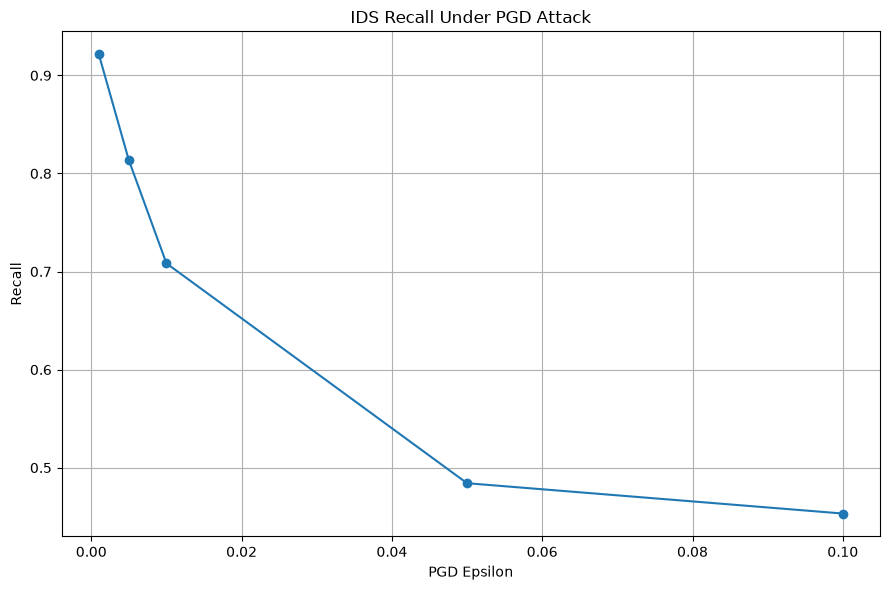

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    pgd_df["Epsilon"],
    pgd_df["Recall"],
    marker="o"
)

plt.xlabel("PGD Epsilon")
plt.ylabel("Recall")

plt.title(
    "IDS Recall Under PGD Attack"
)

plt.grid(True)

plt.tight_layout()

plt.show()

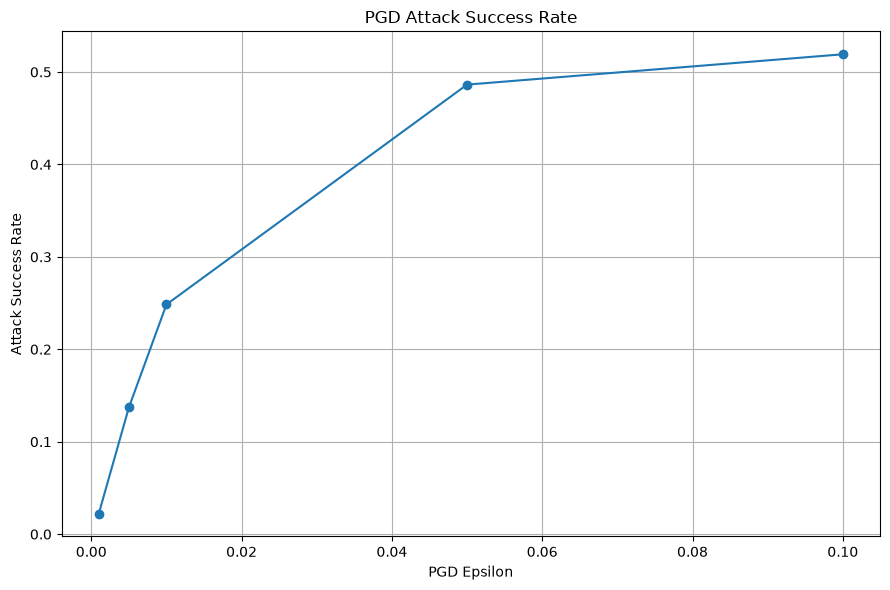

In [23]:
plt.figure(figsize=(9, 6))

plt.plot(
    pgd_df["Epsilon"],
    pgd_df["Attack Success Rate"],
    marker="o"
)

plt.xlabel("PGD Epsilon")

plt.ylabel(
    "Attack Success Rate"
)

plt.title(
    "PGD Attack Success Rate"
)

plt.grid(True)

plt.tight_layout()

plt.show()